In [ ]:
import numpy as np
import ot
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import time
from concurrent.futures import ProcessPoolExecutor, as_completed

In [ ]:
dimensions = [3, 5, 10] # dimension
N = 2000 # support size of base measures
sample_sizes = np.arange(10,101,10)
T = 100 # number of iterations per sample size

In [ ]:
# Setting A

def k_star(x):
  y = x.copy()
  if np.random.rand() < 0.5:
    y[0] += 1
  else:
    y[0] -= 1
  return y

np.random.seed(1234)
mu_by_dimension = {}
nu_by_dimension = {}
for d in dimensions:
  mu_by_dimension[d] = np.concatenate((np.zeros((N,1)), np.random.rand(N,d-1)), axis=1)
  nu_by_dimension[d] = np.concatenate((np.zeros((N,1)), np.random.rand(N,d-1)), axis=1)
  nu_by_dimension[d] = np.apply_along_axis(k_star, 1, nu_by_dimension[d])

In [ ]:
NN_E1_errors = {}
NN_L1_errors = {}
for d in dimensions:
  print(f'd:{d}')
  mu = mu_by_dimension[d]
  nu = nu_by_dimension[d]

  C = ot.dist(mu, nu, metric='euclidean')
  pi_N = ot.emd(np.ones(N)/N, np.ones(N)/N, C)
  sigma_N = pi_N.argmax(axis=1)
  opt_destinations = nu[sigma_N]

  for n in sample_sizes:
    print(f'n:{n}')
    NN_E1_errors[(d,n)] = []
    NN_L1_errors[(d,n)] = []
    for t in range(T):
      indices_mu = np.random.choice(N, n, replace=True)
      indices_nu = np.random.choice(N, n, replace=True)
      mu_n = mu[indices_mu,:]
      nu_n = nu[indices_nu,:]

      # compute NN estimator
      C = ot.dist(mu_n, nu_n, metric='euclidean')
      pi_n = ot.emd(np.ones(n)/n, np.ones(n)/n, C)
      sigma_n = pi_n.argmax(axis=1)
      tree = cKDTree(mu_n)
      _, nn_indices = tree.query(mu)
      destinations = nu_n[sigma_n[nn_indices]]

      NN_L1_errors[(d,n)].append(np.linalg.norm(destinations - opt_destinations, axis=1).mean())

      L1_transport_cost = np.linalg.norm(destinations - mu, axis=1).mean()
      opt_gap = max(L1_transport_cost - 1,0)
      C = ot.dist(destinations, nu, metric='euclidean')
      feas_gap = ot.emd2(np.ones(N)/N, np.ones(N)/N, C)
      NN_E1_errors[(d,n)].append(opt_gap + feas_gap)

In [ ]:
import pickle
with open('NN_errors_plot1.pkl', 'wb') as f:
  pickle.dump((NN_E1_errors,NN_L1_errors), f)

In [ ]:
rounding_E1_errors = {}
for d in dimensions:
  print(f'd:{d}')
  mu = np.concatenate((np.zeros((N,1)), np.random.rand(N,d-1)), axis=1)
  nu = np.concatenate((np.zeros((N,1)), np.random.rand(N,d-1)), axis=1)
  nu = np.apply_along_axis(k_star, 1, nu)

  for n in sample_sizes:
    print(f'n:{n}')
    rounding_E1_errors[(d,n)] = []
    for t in range(T):
      indices_mu = np.random.choice(N, n, replace=True)
      indices_nu = np.random.choice(N, n, replace=True)
      mu_n = mu[indices_mu,:]
      nu_n = nu[indices_nu,:]

      # compute rounding estimator
      delta = n**(-1/(d+2))
      mu_n_rounded = delta * np.round(mu_n / delta)
      C = ot.dist(mu_n_rounded, nu_n, metric='euclidean')
      pi_n = ot.emd(np.ones(n)/n, np.ones(n)/n, C)

      mu_rounded = delta * np.round(mu / delta)
      tree = cKDTree(mu_n_rounded)
      _, nn_indices = tree.query(mu_rounded)
      kernel_dists_raw = pi_n[nn_indices,:] # N x n
      row_sums = kernel_dists_raw.sum(axis=1, keepdims=True)
      kernel_dists = kernel_dists_raw / row_sums

      L1_transport_cost = 0
      for k in range(N):
        for l in range(n):
          L1_transport_cost += np.linalg.norm(mu[k,:] - nu_n[l,:]) * kernel_dists[k,l]
      L1_transport_cost /= N

      destination_weights = kernel_dists.mean(axis=0)

      opt_gap = max(L1_transport_cost - 1,0)
      C = ot.dist(nu_n, nu, metric='euclidean')
      feas_gap = ot.emd2(destination_weights, np.ones(N)/N, C)
      rounding_E1_errors[(d,n)].append(opt_gap + feas_gap)

In [ ]:
import pickle
with open('rounding_errors_plot1_23510_1pm.pkl', 'wb') as f:
  pickle.dump(rounding_E1_errors, f)

In [ ]:
# Setting B

def k_star(x):
  return x + np.sign(x-np.ones(x.shape)/2)

np.random.seed(1234)
mu_by_dimension = {}
nu_by_dimension = {}
for d in dimensions:
  mu_by_dimension[d] = np.random.rand(N,d)
  nu_by_dimension[d] = np.random.rand(N,d)
  nu_by_dimension[d] = np.apply_along_axis(k_star, 1, nu_by_dimension[d])

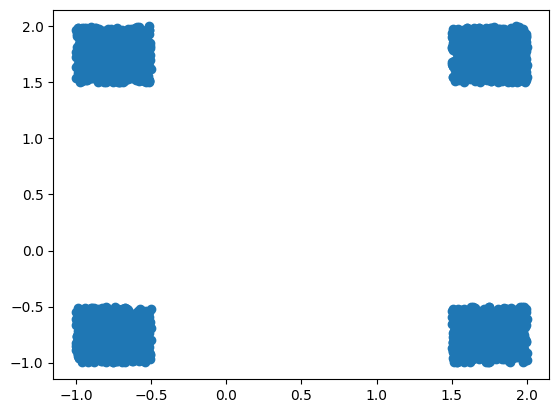

In [16]:
plt.scatter(nu_by_dimension[2][:,0], nu_by_dimension[2][:,1])

In [ ]:
NN_E1_errors = {}
NN_L1_errors = {}

for d in dimensions:
  mu = mu_by_dimension[d]
  nu = nu_by_dimension[d]

  C = ot.dist(mu, nu, metric='euclidean')
  pi_N = ot.emd(np.ones(N)/N, np.ones(N)/N, C)
  sigma_N = pi_N.argmax(axis=1)
  opt_destinations = nu[sigma_N]

  for n in sample_sizes:
    print(f'd: {d}, n:{n}')
    NN_E1_errors[(d,n)] = []
    NN_L1_errors[(d,n)] = []
    for t in range(T):
      indices_mu = np.random.choice(N, n, replace=True)
      indices_nu = np.random.choice(N, n, replace=True)
      mu_n = mu[indices_mu,:]
      nu_n = nu[indices_nu,:]

      # compute NN estimator
      C = ot.dist(mu_n, nu_n, metric='euclidean')
      pi_n = ot.emd(np.ones(n)/n, np.ones(n)/n, C)
      sigma_n = pi_n.argmax(axis=1)
      tree = cKDTree(mu_n)
      _, nn_indices = tree.query(mu)
      destinations = nu_n[sigma_n[nn_indices]]

      NN_L1_errors[(d,n)].append(np.linalg.norm(destinations - opt_destinations, axis=1).mean())

      L1_transport_cost = np.linalg.norm(destinations - mu, axis=1).mean()
      opt_gap = max(L1_transport_cost - np.sqrt(d),0)
      C = ot.dist(destinations, nu, metric='euclidean')
      feas_gap = ot.emd2(np.ones(N)/N, np.ones(N)/N, C)
      NN_E1_errors[(d,n)].append(opt_gap + feas_gap)
    print(np.mean(NN_E1_errors[(d,n)]))

In [ ]:
import pickle
with open('NN_errors_plot2.pkl', 'wb') as f:
  pickle.dump((NN_E1_errors,NN_L1_errors), f)

In [ ]:
rounding_E1_errors = {}
for d in dimensions:
  print(f'd:{d}')
  mu = np.concatenate((np.zeros((N,1)), np.random.rand(N,d-1)), axis=1)
  nu = np.concatenate((np.zeros((N,1)), np.random.rand(N,d-1)), axis=1)
  nu = np.apply_along_axis(k_star, 1, nu)

  for n in sample_sizes:
    print(f'n:{n}')
    rounding_E1_errors[(d,n)] = []
    for t in range(T):
      indices_mu = np.random.choice(N, n, replace=True)
      indices_nu = np.random.choice(N, n, replace=True)
      mu_n = mu[indices_mu,:]
      nu_n = nu[indices_nu,:]

      # compute rounding estimator
      delta = n**(-1/(d+2))
      mu_n_rounded = delta * np.round(mu_n / delta)
      C = ot.dist(mu_n_rounded, nu_n, metric='euclidean')
      pi_n = ot.emd(np.ones(n)/n, np.ones(n)/n, C)

      mu_rounded = delta * np.round(mu / delta)
      tree = cKDTree(mu_n_rounded)
      _, nn_indices = tree.query(mu_rounded)
      kernel_dists_raw = pi_n[nn_indices,:] # N x n
      row_sums = kernel_dists_raw.sum(axis=1, keepdims=True)
      kernel_dists = kernel_dists_raw / row_sums

      L1_transport_cost = 0
      for k in range(N):
        for l in range(n):
          L1_transport_cost += np.linalg.norm(mu[k,:] - nu_n[l,:]) * kernel_dists[k,l]
      L1_transport_cost /= N

      destination_weights = kernel_dists.mean(axis=0)

      opt_gap = max(L1_transport_cost - np.sqrt(d),0)
      C = ot.dist(nu_n, nu, metric='euclidean')
      feas_gap = ot.emd2(destination_weights, np.ones(N)/N, C)
      rounding_E1_errors[(d,n)].append(opt_gap + feas_gap)

In [ ]:
import pickle
with open('rounding_errors_plot2.pkl', 'wb') as f:
  pickle.dump(rounding_E1_errors, f)